In [24]:
import pandas as pd

# df = pd.read_csv('../data\\two_bedroom_home_values_zhvi.csv')
df = pd.read_csv("../data\\all_house_types/house_prices.csv")
df.head(10)


,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,102001,0,United States,country,NaN,122095.338389,122310.143231,122576.532861,123147.886331,123805.445673,...,362348.966564,362807.919409,362533.073508,362005.958620,361321.678348,360705.615411,360279.804203,360052.608231,360293.712117,360727.121788
1,394913,1,"New York, NY",msa,NY,219565.593260,220498.623149,221440.294575,223348.485266,225324.482808,...,689682.577780,690983.193638,692691.217545,695141.260958,696921.202994,698406.123120,699586.052632,700381.032667,701790.451814,704140.723119
2,753899,2,"Los Angeles, CA",msa,CA,221432.437164,222256.446781,223354.019733,225537.821205,227926.215390,...,963545.812288,961517.697095,956424.504253,952110.252154,947340.204517,942988.929116,940398.465432,939327.828380,940383.909291,942798.595192
3,394463,3,"Chicago, IL",msa,IL,153343.175465,153485.126575,153755.474965,154428.034572,155237.042883,...,328627.381612,329973.195016,330818.586508,331419.158957,331709.573240,332070.288234,332909.054962,333904.160604,335236.319083,336540.250584
4,394514,4,"Dallas, TX",msa,TX,127434.269550,127491.029219,127556.280269,127725.730391,127949.145738,...,374885.871571,374099.667668,372599.443330,370475.677803,368063.324701,365702.998441,363689.498266,362329.533893,361683.472342,361335.422264
5,394692,5,"Houston, TX",msa,TX,123645.474721,123668.506076,123582.175989,123633.779003,123681.381130,...,311012.819926,310864.701269,310224.241010,309304.388291,308361.135568,307374.089190,306536.360521,305823.825123,305356.221526,304956.043931
6,395209,6,"Washington, DC",msa,VA,180758.588634,180905.559374,181176.436174,181789.779111,182722.164641,...,574805.954094,575939.556567,575998.662844,575718.295393,574523.391950,573232.554672,572226.287974,571681.384318,571738.794180,572340.434283
7,394974,7,"Philadelphia, PA",msa,PA,121759.444861,122030.070525,122214.761768,122670.506406,123111.533609,...,368751.036619,369835.175408,370525.751581,371381.414139,372307.041297,373207.935364,374230.498281,374984.084233,375792.244396,376305.857250
8,394856,8,"Miami, FL",msa,FL,114288.006506,114601.751024,114933.990345,115605.186125,116254.710243,...,492442.193393,491692.169987,489721.583953,487091.559815,483861.988681,480652.336763,477080.985601,474127.872800,472134.645904,471191.922620
9,394347,9,"Atlanta, GA",msa,GA,148141.300001,148482.740303,148885.020185,149740.625078,150696.485845,...,387670.580043,386824.327203,385487.939073,384119.481045,382594.412021,381239.337025,379958.553678,379099.195500,378722.906299,378431.732227


In [25]:
# Basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist()[:10], "...")  # Show first 10 columns
print(f"\nTotal columns: {len(df.columns)}")


Dataset Shape: (895, 315)

Column Names:
['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', '2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30', '2000-05-31'] ...

Total columns: 315


In [26]:
df.isna().sum()

RegionID      0
SizeRank      0
RegionName    0
RegionType    0
StateName     1
             ..
2025-06-30    0
2025-07-31    0
2025-08-31    0
2025-09-30    0
2025-10-31    0
Length: 315, dtype: int64

In [27]:
df.duplicated().sum()  

np.int64(0)

In [28]:
# Check for New York in the dataset
print("Unique Region Names (first 20):")
print(df["RegionName"].unique()[:20])
print("\nChecking for New York:")
df_ny = df[df["RegionName"].str.contains("New York", case=False, na=False)]
print(f"Found {len(df_ny)} regions with 'New York' in name:")
print(df_ny[["RegionName", "StateName"]].to_string())


Unique Region Names (first 20):
['United States' 'New York, NY' 'Los Angeles, CA' 'Chicago, IL'
 'Dallas, TX' 'Houston, TX' 'Washington, DC' 'Philadelphia, PA'
 'Miami, FL' 'Atlanta, GA' 'Boston, MA' 'Phoenix, AZ' 'San Francisco, CA'
 'Riverside, CA' 'Detroit, MI' 'Seattle, WA' 'Minneapolis, MN'
 'San Diego, CA' 'Tampa, FL' 'Denver, CO']

Checking for New York:
Found 1 regions with 'New York' in name:
     RegionName StateName
1  New York, NY        NY


In [29]:
df_ny


,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
1,394913,1,"New York, NY",msa,NY,219565.59326,220498.623149,221440.294575,223348.485266,225324.482808,...,689682.57778,690983.193638,692691.217545,695141.260958,696921.202994,698406.12312,699586.052632,700381.032667,701790.451814,704140.723119


In [30]:
import matplotlib.pyplot as plt

# # Filter for New York and save to house_prices_df
# house_prices_df = df[df["RegionName"] == "New York, NY"].copy()
# print(
#     f"Selected region: {house_prices_df[['RegionName', 'StateName']].values}"
# )

# Drop non-date columns
price_data = df_ny.loc[:, "2000-01-31":]

# Convert to long format
price_long = price_data.melt(var_name="Date", value_name="MedianPrice")

# Convert Date column to datetime
price_long["Date"] = pd.to_datetime(price_long["Date"])

# Sort by date
price_long = price_long.sort_values("Date")

# Basic stats on the price data
print(f"\nPrice data statistics:")
print(price_long["MedianPrice"].describe())
print(f"\nDate range: {price_long['Date'].min()} to {price_long['Date'].max()}")
print(f"Total data points: {len(price_long)}")
print(f"Missing values: {price_long['MedianPrice'].isna().sum()}")



Price data statistics:
count       310.000000
mean     447563.391346
std      113558.871994
min      219565.593260
25%      385064.399657
50%      435006.070899
75%      500319.656782
max      704140.723119
Name: MedianPrice, dtype: float64

Date range: 2000-01-31 00:00:00 to 2025-10-31 00:00:00
Total data points: 310
Missing values: 0


In [31]:
price_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         310 non-null    datetime64[ns]
 1   MedianPrice  310 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.0 KB


In [32]:
price_long.head()

,Date,MedianPrice
0,2000-01-31,219565.593260
1,2000-02-29,220498.623149
2,2000-03-31,221440.294575
3,2000-04-30,223348.485266
4,2000-05-31,225324.482808


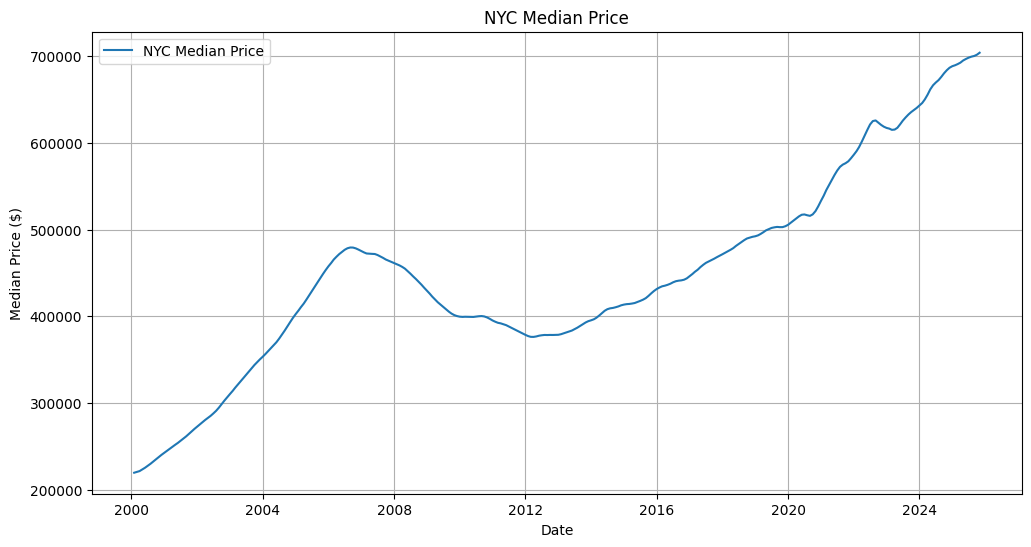

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(
    price_long["Date"], price_long["MedianPrice"], label="NYC Median Price"
)
plt.title("NYC Median Price")
plt.xlabel("Date")
plt.ylabel("Median Price ($)")
plt.legend()
plt.grid(True)
plt.show()


In [34]:
# ============================================
# RENTAL PRICES PREPROCESSING
# ============================================
# Read rental prices data
df_rental = pd.read_csv("../data\\all_house_types\\rental_prices.csv")
df_rental.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,102001,0,United States,country,NaN,1169.772412,1175.085650,1180.838081,1185.609374,1189.845204,...,1917.664558,1922.108609,1925.659715,1928.682975,1931.100321,1934.540276,1937.740062,1941.692183,1945.360252,1948.708033
1,394913,1,"New York, NY",msa,NY,2253.797699,2268.524506,2281.696842,2291.346295,2295.188966,...,3268.737429,3280.953001,3290.899185,3300.889251,3310.015619,3324.468464,3344.371424,3365.310105,3382.543031,3397.903293
2,753899,2,"Los Angeles, CA",msa,CA,1770.506451,1779.655938,1790.485212,1800.969293,1809.482271,...,2881.873783,2892.123481,2900.050387,2899.978306,2901.469674,2905.115272,2908.453765,2914.444302,2919.350344,2924.884110
3,394463,3,"Chicago, IL",msa,IL,1346.982122,1348.642766,1352.992740,1356.809490,1360.767858,...,1990.098730,1999.744363,2009.580494,2019.788653,2029.804518,2039.826012,2050.385991,2059.932501,2069.593198,2076.789127
4,394514,4,"Dallas, TX",msa,TX,1073.737067,1077.425243,1081.184784,1087.591126,1092.002629,...,1678.215833,1680.828202,1680.990903,1682.577990,1680.738179,1680.544332,1678.720668,1678.249588,1678.890790,1678.471598


In [35]:
# Basic information
print("Dataset Shape:", df_rental.shape)
print("\nColumn Names (first 10):")
print(df_rental.columns.tolist()[:10])
print(f"\nTotal columns: {len(df_rental.columns)}")

Dataset Shape: (707, 135)

Column Names (first 10):
['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', '2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30', '2015-05-31']

Total columns: 135


In [36]:
# Data types and info
df_rental.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 707 entries, 0 to 706
Columns: 135 entries, RegionID to 2025-10-31
dtypes: float64(130), int64(2), object(3)
memory usage: 745.8+ KB


In [37]:
# Check for New York
print("Checking for New York:")
ny_rental = df_rental[
    df_rental["RegionName"].str.contains("New York", case=False, na=False)
]
print(f"Found {len(ny_rental)} regions with 'New York' in name:")
print(ny_rental[["RegionName", "StateName"]].to_string())


Checking for New York:
Found 1 regions with 'New York' in name:
     RegionName StateName
1  New York, NY        NY


In [38]:
ny_rental

,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
1,394913,1,"New York, NY",msa,NY,2253.797699,2268.524506,2281.696842,2291.346295,2295.188966,...,3268.737429,3280.953001,3290.899185,3300.889251,3310.015619,3324.468464,3344.371424,3365.310105,3382.543031,3397.903293


In [40]:
print(f"Selected region: {ny_rental[['RegionName', 'StateName']].values}")
print(f"Shape: {ny_rental.shape}")


Selected region: [['New York, NY' 'NY']]
Shape: (1, 135)


In [43]:
# Drop non-date columns
rental_price_data = ny_rental.loc[:, "2015-01-31":]  # Adjust start date as needed

# Convert to long format
rental_long = rental_price_data.melt(var_name="Date", value_name="RentalPrice")

# Convert Date column to datetime
rental_long["Date"] = pd.to_datetime(rental_long["Date"])

# Sort by date
rental_long = rental_long.sort_values("Date")

# Set Date as index
rental_long = rental_long.set_index("Date")

# Basic stats on the rental data
print(f"\nRental data statistics:")
print(rental_long["RentalPrice"].describe())
print(f"\nDate range: {rental_long.index.min()} to {rental_long.index.max()}")
print(f"Total data points: {len(rental_long)}")
print(f"Missing values: {rental_long['RentalPrice'].isna().sum()}")



Rental data statistics:
count     123.000000
mean     2684.491267
std       360.250974
min      2253.797699
25%      2387.146941
50%      2505.139714
75%      3043.298690
max      3397.903293
Name: RentalPrice, dtype: float64

Date range: 2015-01-31 00:00:00 to 2025-10-31 00:00:00
Total data points: 130
Missing values: 7


In [44]:
# Verify ready for time series
print("Date range:", rental_long.index.min(), "to", rental_long.index.max())
print("Total points:", len(rental_long))
print("Date is datetime:", pd.api.types.is_datetime64_any_dtype(rental_long.index))
print("No missing:", rental_long["RentalPrice"].isna().sum() == 0)
print("No duplicates:", rental_long.index.duplicated().sum() == 0)
print("Is sorted:", rental_long.index.is_monotonic_increasing)


Date range: 2015-01-31 00:00:00 to 2025-10-31 00:00:00
Total points: 130
Date is datetime: True
No missing: False
No duplicates: True
Is sorted: True


In [45]:
rental_long

,RentalPrice
Date,
2015-01-31,2253.797699
2015-02-28,2268.524506
2015-03-31,2281.696842
2015-04-30,2291.346295
2015-05-31,2295.188966
...,...
2025-06-30,3324.468464
2025-07-31,3344.371424
2025-08-31,3365.310105
